In [1]:
!pip install pygam

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import (StandardScaler, PolynomialFeatures,
                                    KBinsDiscretizer, SplineTransformer)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             f1_score, mean_squared_error, mean_absolute_error, r2_score)
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               GradientBoostingClassifier,
                               BaggingRegressor, RandomForestRegressor,
                               GradientBoostingRegressor)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [3]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/wyattowalsh/basketball/csv/game.csv')
print(f"Raw dataset shape: {df.shape}")

# Filter to modern era (post-1979, 3-point line era)
df['game_date'] = pd.to_datetime(df['game_date'])
df = df[df['game_date'] >= '1979-01-01'].copy()
df = df.dropna(subset=['wl_home'])

# ── SHARED features (no points, no plus_minus — used for BOTH tasks) ──
shared_features = [
    'fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home',
    'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home',
    'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home',
    'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg3_pct_away',
    'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away',
    'ast_away', 'stl_away', 'blk_away', 'tov_away', 'pf_away'
]

# ── CLASSIFICATION features (include pts for Win/Loss prediction) ──
clf_features = shared_features + ['pts_home', 'pts_away']

# Clean dataset — drop rows with any NaN in the union of all needed columns
all_cols = clf_features + ['wl_home']
df_clean = df[all_cols].dropna().reset_index(drop=True)

# Targets
df_clean['target_wl'] = (df_clean['wl_home'] == 'W').astype(int)

print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Win/Loss distribution: {df_clean['target_wl'].value_counts().to_dict()}")
print(f"Home win rate: {df_clean['target_wl'].mean():.3f}")
print(f"pts_home range: {df_clean['pts_home'].min():.0f} – {df_clean['pts_home'].max():.0f}")
print(f"pts_away range: {df_clean['pts_away'].min():.0f} – {df_clean['pts_away'].max():.0f}")


Raw dataset shape: (65698, 55)

Cleaned dataset shape: (46154, 38)
Win/Loss distribution: {1: 27848, 0: 18306}
Home win rate: 0.603
pts_home range: 49 – 192
pts_away range: 53 – 196


In [4]:
# ── Train / Test Split (shared index for both tasks) ──────

X_clf = df_clean[clf_features]        # Classification: all box-score stats incl. pts
X_reg = df_clean[shared_features]     # Regression: no pts (that's the target)
y_clf = df_clean['target_wl']         # Binary: 1=Win, 0=Loss
y_reg = df_clean[['pts_home', 'pts_away']]  # Multi-output regression

# Same split indices for both tasks
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

X_reg_train = X_reg.loc[X_clf_train.index]
X_reg_test  = X_reg.loc[X_clf_test.index]
y_reg_train = y_reg.loc[X_clf_train.index]
y_reg_test  = y_reg.loc[X_clf_test.index]

# Scaled versions
scaler_clf = StandardScaler()
X_clf_train_s = scaler_clf.fit_transform(X_clf_train)
X_clf_test_s  = scaler_clf.transform(X_clf_test)

scaler_reg = StandardScaler()
X_reg_train_s = scaler_reg.fit_transform(X_reg_train)
X_reg_test_s  = scaler_reg.transform(X_reg_test)

print(f"Training set: {X_clf_train.shape[0]} samples")
print(f"Test set:     {X_clf_test.shape[0]} samples")
print(f"Classification features: {X_clf_train.shape[1]}")
print(f"Regression features:     {X_reg_train.shape[1]} (pts excluded — they are targets)")

Training set: 36923 samples
Test set:     9231 samples
Classification features: 36
Regression features:     34 (pts excluded — they are targets)


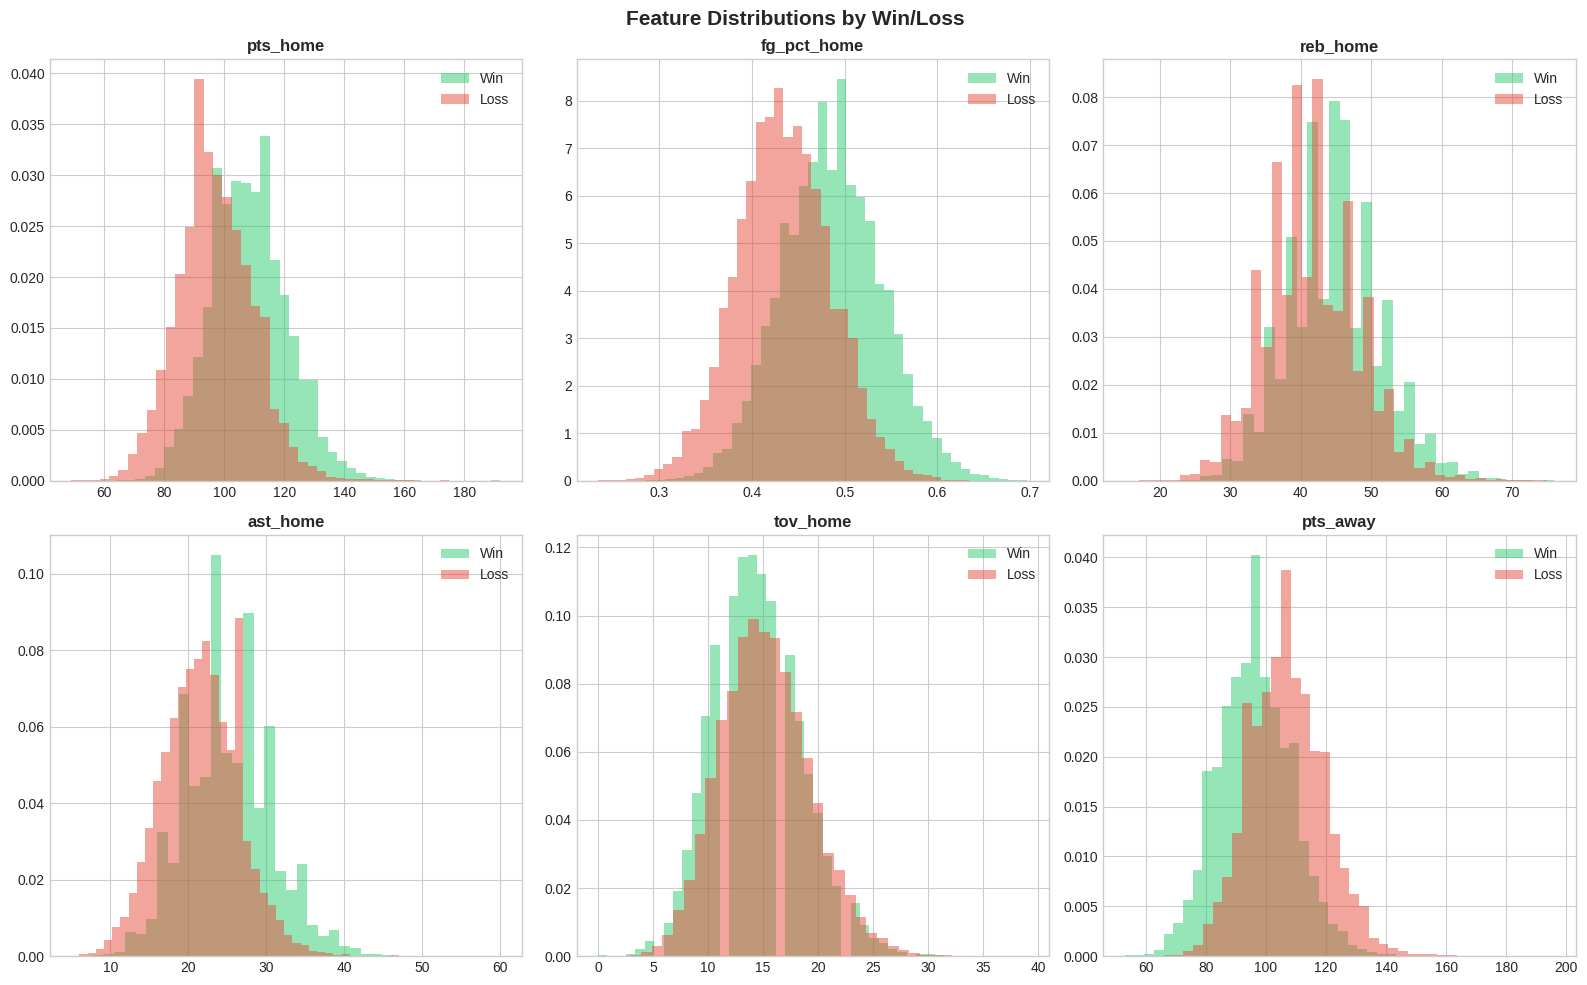

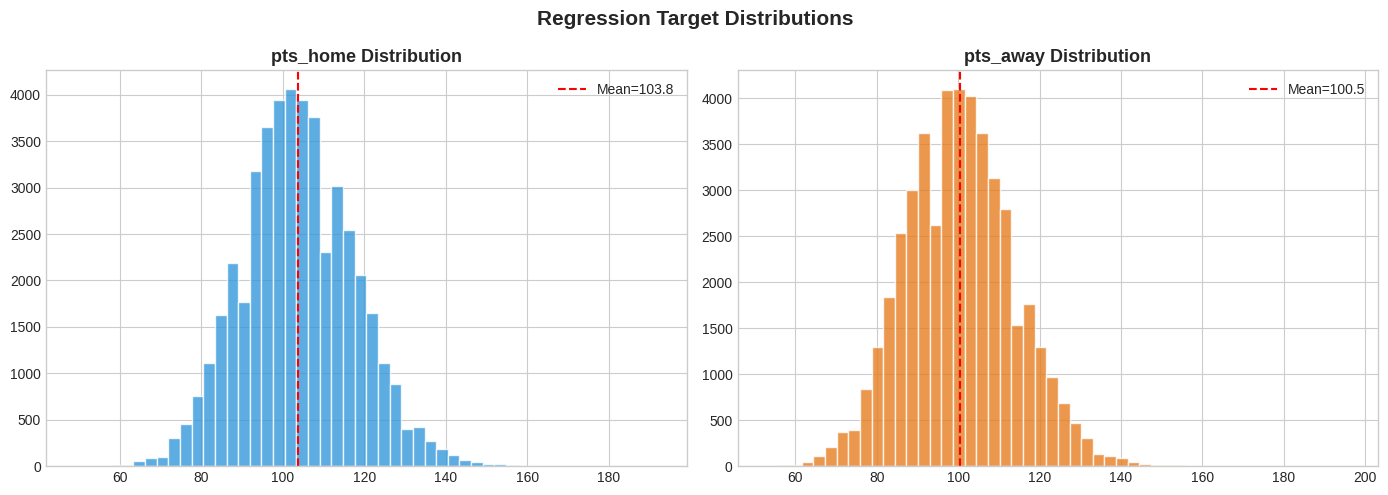

In [5]:
# ── Quick EDA ──────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

eda_feats = ['pts_home', 'fg_pct_home', 'reb_home', 'ast_home', 'tov_home', 'pts_away']
for ax, feat in zip(axes.ravel(), eda_feats):
    for label, color in [(1, '#2ecc71'), (0, '#e74c3c')]:
        subset = df_clean[df_clean['target_wl'] == label]
        ax.hist(subset[feat], bins=40, alpha=0.5, color=color,
                label='Win' if label == 1 else 'Loss', density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Feature Distributions by Win/Loss', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Regression targets distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color in zip(axes, ['pts_home', 'pts_away'], ['#3498db', '#e67e22']):
    ax.hist(df_clean[col], bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean={df_clean[col].mean():.1f}')
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.legend()
plt.suptitle('Regression Target Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
# ── Classification helper ──────────────────────────────────
clf_results = {}

def eval_clf(name, model, X_tr, y_tr, X_te, y_te, scale=False):
    if scale:
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    try:
        y_prob = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_prob)
    except:
        try:
            y_prob = model.decision_function(X_te)
            auc = roc_auc_score(y_te, y_prob)
        except:
            y_prob = None; auc = None
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    clf_results[name] = {'accuracy': acc, 'f1_score': f1, 'auc': auc,
                         'y_pred': y_pred, 'y_prob': y_prob}
    print(f"  {name}: Acc={acc:.4f} | F1={f1:.4f}" + (f" | AUC={auc:.4f}" if auc else ""))
    return model

# Non-linear Models

In [7]:
# A1a) POLYNOMIAL LOGISTIC REGRESSION (degree=2)
poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ('clf', LogisticRegression(max_iter=2000, C=0.1, random_state=RANDOM_STATE))
])
poly_pipe.fit(X_clf_train, y_clf_train)
y_pred = poly_pipe.predict(X_clf_test)
y_prob = poly_pipe.predict_proba(X_clf_test)[:, 1]
acc = accuracy_score(y_clf_test, y_pred)
f1 = f1_score(y_clf_test, y_pred)
auc = roc_auc_score(y_clf_test, y_prob)
clf_results['Polynomial (deg=2)'] = {'accuracy': acc, 'f1_score': f1, 'auc': auc,
                                      'y_pred': y_pred, 'y_prob': y_prob}
print(f"Polynomial features generated: {poly_pipe.named_steps['poly'].n_output_features_}")
print(f"  Polynomial (deg=2): Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")


Polynomial features generated: 702
  Polynomial (deg=2): Acc=0.9979 | F1=0.9983 | AUC=1.0000


In [8]:
# A1b) STEP FUNCTIONS
for n_bins in [5, 10]:
    pipe = Pipeline([
        ('bins', KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense',
                                   strategy='quantile', subsample=None)),
        ('clf', LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE))
    ])
    name = f'Step Function ({n_bins} bins)'
    pipe.fit(X_clf_train, y_clf_train)
    y_pred = pipe.predict(X_clf_test)
    y_prob = pipe.predict_proba(X_clf_test)[:, 1]
    acc = accuracy_score(y_clf_test, y_pred)
    f1v = f1_score(y_clf_test, y_pred)
    auc = roc_auc_score(y_clf_test, y_prob)
    clf_results[name] = {'accuracy': acc, 'f1_score': f1v, 'auc': auc,
                          'y_pred': y_pred, 'y_prob': y_prob}
    print(f"  {name}: Acc={acc:.4f} | F1={f1v:.4f} | AUC={auc:.4f}")


  Step Function (5 bins): Acc=0.9509 | F1=0.9596 | AUC=0.9908
  Step Function (10 bins): Acc=0.9752 | F1=0.9795 | AUC=0.9974


In [30]:
# A1c) SPLINES
for n_knots in [4, 6]:
    spline_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('spline', SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)),
        ('clf', LogisticRegression(max_iter=2000, C=0.1, random_state=RANDOM_STATE))
    ])
    name = f'Spline ({n_knots} knots)'
    pipe.fit(X_clf_train, y_clf_train)
    y_pred = pipe.predict(X_clf_test)
    y_prob = pipe.predict_proba(X_clf_test)[:, 1]
    acc = accuracy_score(y_clf_test, y_pred)
    f1v = f1_score(y_clf_test, y_pred)
    auc = roc_auc_score(y_clf_test, y_prob)
    clf_results[name] = {'accuracy': acc, 'f1_score': f1v, 'auc': auc,
                          'y_pred': y_pred, 'y_prob': y_prob}
    print(f"  {name}: Acc={acc:.4f} | F1={f1v:.4f} | AUC={auc:.4f}")


  Spline (4 knots): Acc=0.9786 | F1=0.9823 | AUC=0.9982
  Spline (6 knots): Acc=0.9786 | F1=0.9823 | AUC=0.9982


In [10]:
# A1d) LOCAL REGRESSION (distance-weighted KNN)
for k in [5, 15, 50]:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    eval_clf(f'Local Reg (KNN k={k})', knn, X_clf_train_s, y_clf_train, X_clf_test_s, y_clf_test)


  Local Reg (KNN k=5): Acc=0.9124 | F1=0.9288 | AUC=0.9642
  Local Reg (KNN k=15): Acc=0.9301 | F1=0.9432 | AUC=0.9817
  Local Reg (KNN k=50): Acc=0.9384 | F1=0.9503 | AUC=0.9878


In [11]:
from pygam import LogisticGAM, s

terms = s(0)
for i in range(1, X_clf_train_s.shape[1]):
    terms += s(i)

gam_clf = LogisticGAM(terms)
gam_clf.fit(X_clf_train_s, y_clf_train)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + s(11) + s(12) + s(13) + s(14) + s(15) + s(16) + s(17) + s(18) + s(19) + s(20) + s(21) + s(22) + s(23) + s(24) + s(25) + s(26) + s(27) + s(28) + s(29) + s(30) + s(31) + s(32) + s(33) + s(34) + s(35) + intercept,
   tol=0.0001, verbose=False)

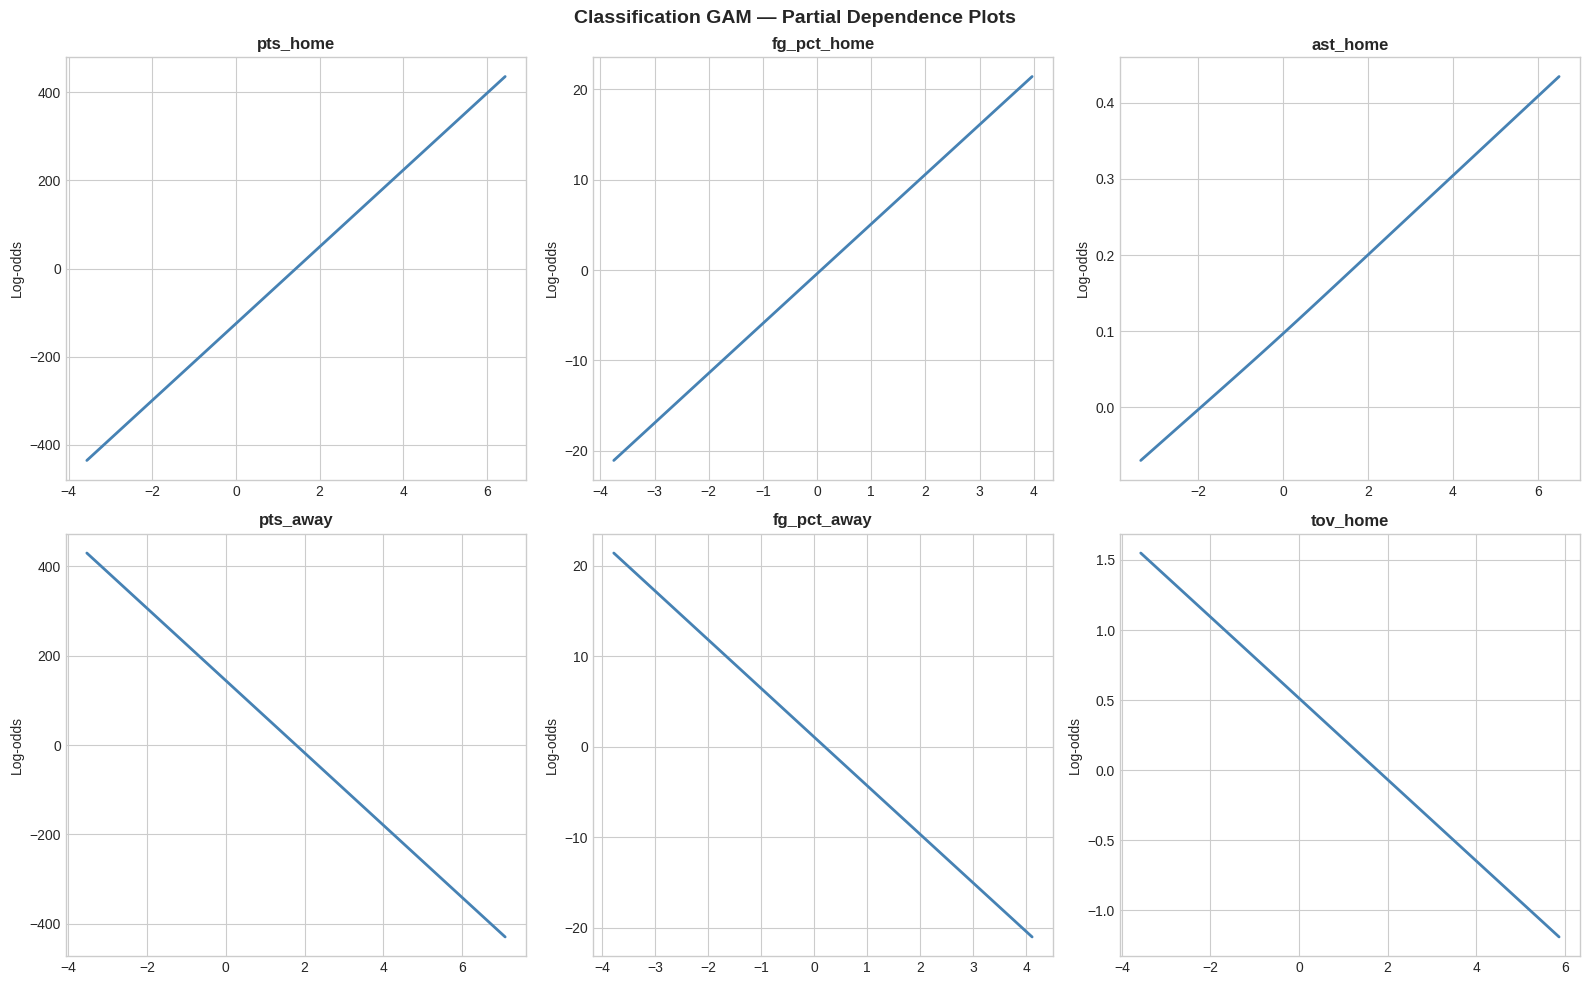

In [12]:
# GAM partial dependence plots (top 6 features)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
top_idx = [clf_features.index(f) for f in ['pts_home','fg_pct_home','ast_home',
                                             'pts_away','fg_pct_away','tov_home']]
for ax, idx in zip(axes.ravel(), top_idx):
    XX = gam_clf.generate_X_grid(term=idx)
    ax.plot(XX[:, idx], gam_clf.partial_dependence(term=idx, X=XX), lw=2, color='steelblue')
    ax.set_title(f'{clf_features[idx]}', fontweight='bold')
    ax.set_ylabel('Log-odds')
plt.suptitle('Classification GAM — Partial Dependence Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Tree-based Methods

In [13]:
for n_est, max_d in [(200, 15), (500, 20)]:
    eval_clf(f'Random Forest (n={n_est}, d={max_d})',
             RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                     min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
             X_clf_train, y_clf_train, X_clf_test, y_clf_test)

  Random Forest (n=200, d=15): Acc=0.9814 | F1=0.9847 | AUC=0.9987
  Random Forest (n=500, d=20): Acc=0.9818 | F1=0.9850 | AUC=0.9988


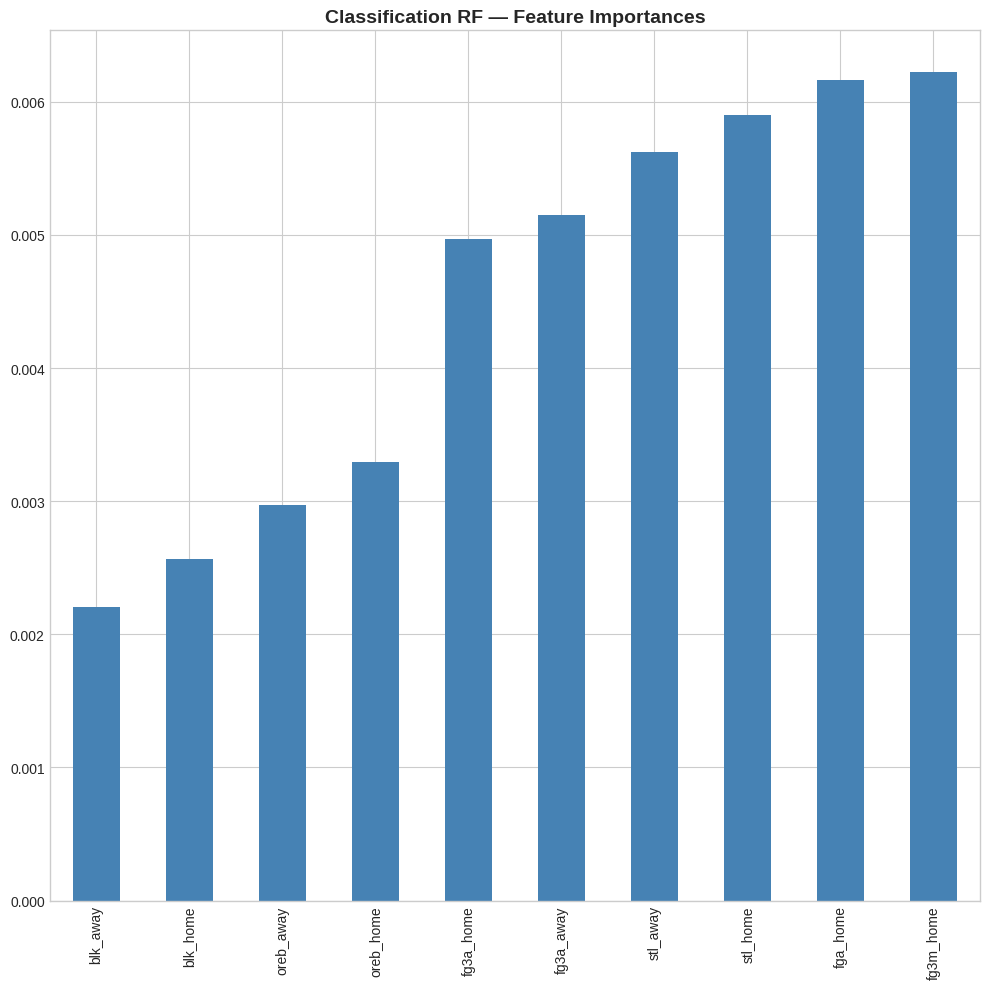

In [14]:
# Feature importances
rf = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=5,
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_clf_train, y_clf_train)
imp = pd.Series(rf.feature_importances_, index=clf_features).sort_values(ascending=True)[:10]

fig, ax = plt.subplots(figsize=(10, 10))
imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Classification RF — Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
for lr, n_est in [(0.1, 200), (0.05, 500)]:
    eval_clf(f'GBoosting (lr={lr}, n={n_est})',
             GradientBoostingClassifier(n_estimators=n_est, learning_rate=lr, max_depth=5,
                                         subsample=0.8, random_state=RANDOM_STATE),
             X_clf_train, y_clf_train, X_clf_test, y_clf_test)

try:
    from xgboost import XGBClassifier
    eval_clf('XGBoost',
             XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                           subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                           use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
             X_clf_train, y_clf_train, X_clf_test, y_clf_test)
except ImportError:
    print("XGBoost not installed — pip install xgboost")


  GBoosting (lr=0.1, n=200): Acc=0.9988 | F1=0.9990 | AUC=1.0000
  GBoosting (lr=0.05, n=500): Acc=0.9987 | F1=0.9989 | AUC=1.0000
  XGBoost: Acc=0.9989 | F1=0.9991 | AUC=1.0000


# SVM

In [16]:
# Custom kernel functions
def kernel_laplacian(X, Y):
    """Laplacian (L1-RBF) — more robust to outliers than Gaussian RBF"""
    from sklearn.metrics.pairwise import manhattan_distances
    gamma = 1.0 / X.shape[1]
    return np.exp(-gamma * manhattan_distances(X, Y))

def kernel_rational_quadratic(X, Y):
    """Rational Quadratic — mixture of RBFs at different scales"""
    alpha, c = 1.0, 1.0
    from sklearn.metrics.pairwise import euclidean_distances
    D2 = euclidean_distances(X, Y) ** 2
    return (1 - D2 / (D2 + c)) ** alpha

def kernel_anova(X, Y, sigma=1.0, d=2):
    """ANOVA kernel — captures feature interaction effects"""
    K = np.zeros((X.shape[0], Y.shape[0]))
    for k in range(X.shape[1]):
        K += np.exp(-sigma * (X[:, k:k+1] - Y[:, k].reshape(1, -1)) ** 2) ** d
    return K

def kernel_cosine_custom(X, Y):
    """Cosine similarity — useful when direction matters more than magnitude"""
    from sklearn.metrics.pairwise import cosine_similarity
    return cosine_similarity(X, Y)

In [17]:
# ── Imports needed by custom kernels ──────────────────────────────────────
from sklearn.metrics.pairwise import manhattan_distances, euclidean_distances, cosine_similarity

# ── Subsample for SVM efficiency ──────────────────────────────────────────
from sklearn.utils import resample
n_svm = min(20000, len(X_clf_train_s))
idx_svm = resample(np.arange(len(X_clf_train_s)), n_samples=n_svm,
                   random_state=RANDOM_STATE, replace=False)
X_svm_tr = X_clf_train_s[idx_svm]
y_svm_tr = y_clf_train.iloc[idx_svm]
print(f"SVM training on {n_svm} subsampled samples\n")

# ── All kernels ────────────────────────────────────────────────────────────
kernels = {
    # Built-in kernels
    'SVM Linear':            SVC(kernel='linear',  C=1.0, probability=True, random_state=RANDOM_STATE),
    'SVM Poly':              SVC(kernel='poly',     degree=3, C=1.0, probability=True, random_state=RANDOM_STATE),
    'SVM RBF':               SVC(kernel='rbf',      C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'SVM Sigmoid':           SVC(kernel='sigmoid',  C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),
    # Custom kernels
    'SVM Laplacian':         SVC(kernel=kernel_laplacian,         C=1.0, probability=True, random_state=RANDOM_STATE),
    'SVM Rational Quadratic':SVC(kernel=kernel_rational_quadratic,C=1.0, probability=True, random_state=RANDOM_STATE),
    'SVM ANOVA':             SVC(kernel=kernel_anova,             C=1.0, probability=True, random_state=RANDOM_STATE),
    'SVM Cosine':            SVC(kernel=kernel_cosine_custom,     C=1.0, probability=True, random_state=RANDOM_STATE),
}

for name, svm in kernels.items():
    eval_clf(name, svm, X_svm_tr, y_svm_tr, X_clf_test_s, y_clf_test)

SVM training on 20000 subsampled samples

  SVM Linear: Acc=1.0000 | F1=1.0000 | AUC=1.0000
  SVM Poly: Acc=0.9742 | F1=0.9787 | AUC=0.9978
  SVM RBF: Acc=0.9903 | F1=0.9919 | AUC=0.9997
  SVM Sigmoid: Acc=0.9281 | F1=0.9404 | AUC=0.9744
  SVM Laplacian: Acc=0.9866 | F1=0.9889 | AUC=0.9993
  SVM Rational Quadratic: Acc=0.9729 | F1=0.9777 | AUC=0.9978
  SVM ANOVA: Acc=0.9930 | F1=0.9942 | AUC=0.9996
  SVM Cosine: Acc=0.9932 | F1=0.9944 | AUC=0.9998


PCA explains 27.4% of variance


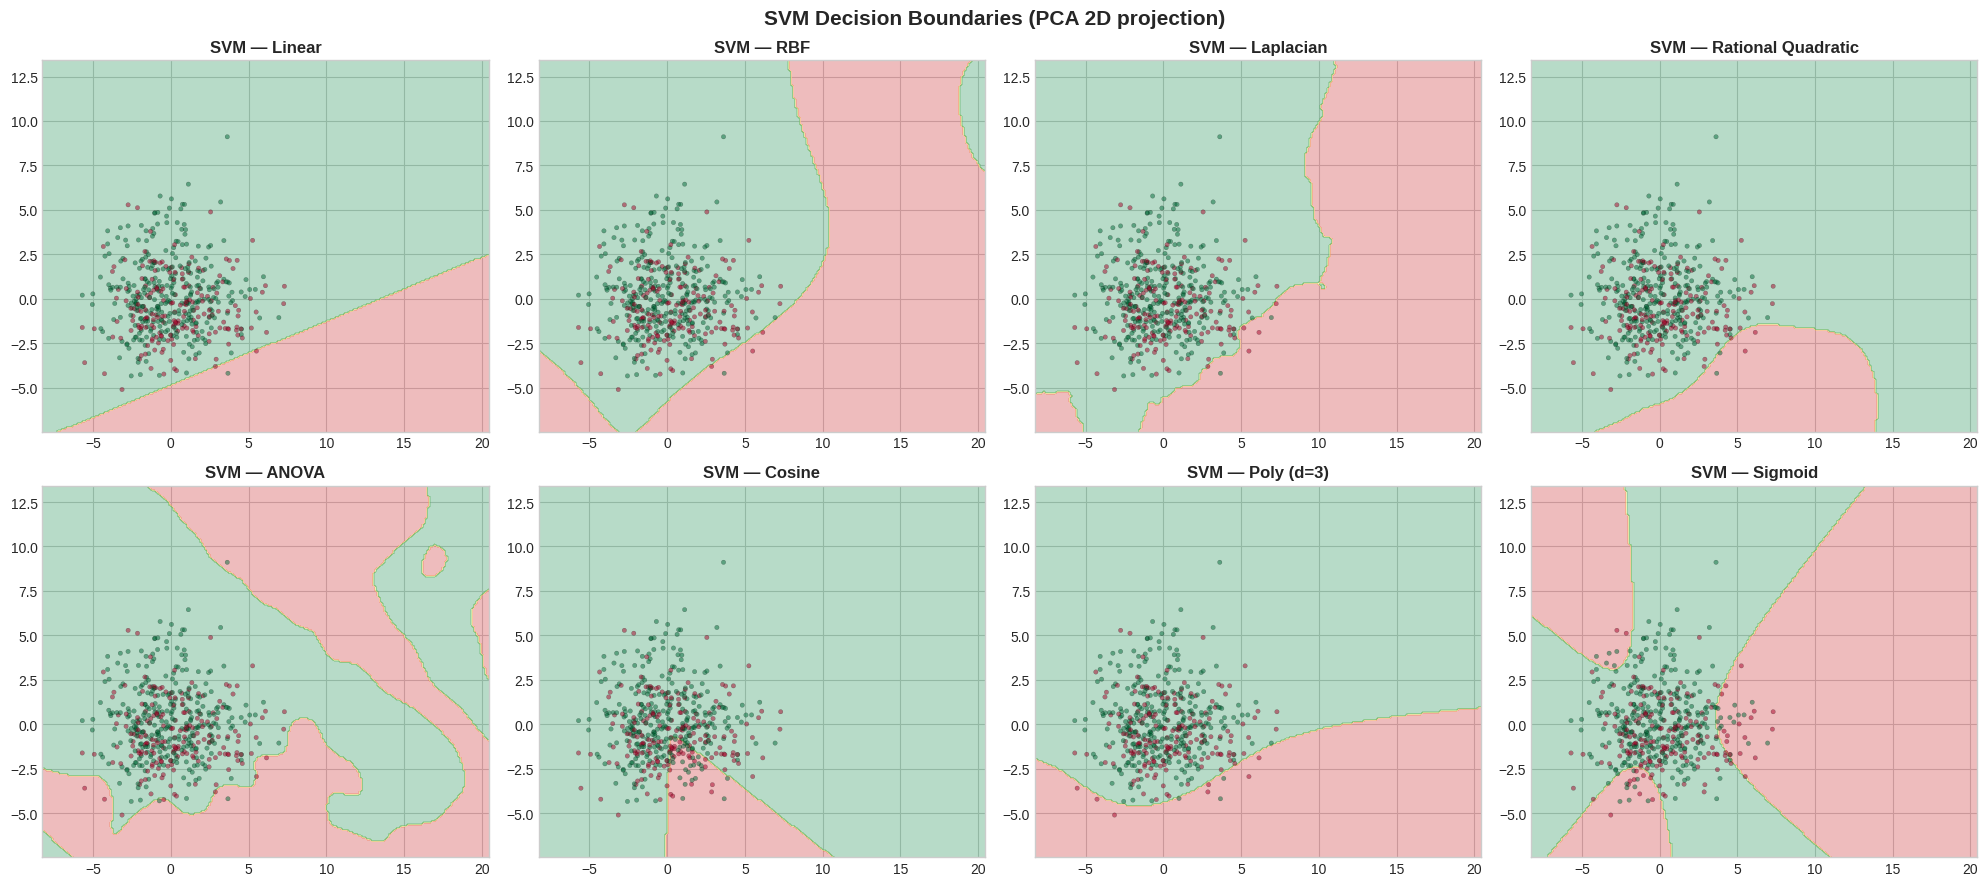

In [19]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import numpy as np

# --- Train SVMs on FULL feature space (no PCA) ---
kernel_configs = [
    ('Linear',             'linear'),
    ('RBF',                'rbf'),
    ('Laplacian',          kernel_laplacian),
    ('Rational Quadratic', kernel_rational_quadratic),
    ('ANOVA',              kernel_anova),
    ('Cosine',             kernel_cosine_custom),
    ('Poly (d=3)',         'poly'),
    ('Sigmoid',            'sigmoid'),
]

trained_svms = {}
for lbl, kern in kernel_configs:
    svm = SVC(kernel=kern, C=1.0, gamma='scale', random_state=RANDOM_STATE)
    svm.fit(X_svm_tr, y_svm_tr)          # full-dimensional training
    trained_svms[lbl] = svm

# --- PCA only for 2D plotting ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_tr = pca.fit_transform(X_svm_tr)
X_pca_te = pca.transform(X_clf_test_s)
print(f"PCA explains {pca.explained_variance_ratio_.sum():.1%} of variance")

xx, yy = np.meshgrid(
    np.linspace(X_pca_tr[:, 0].min() - 1, X_pca_tr[:, 0].max() + 1, 200),
    np.linspace(X_pca_tr[:, 1].min() - 1, X_pca_tr[:, 1].max() + 1, 200)
)
grid_pca = np.c_[xx.ravel(), yy.ravel()]

# Project grid back to original feature space for prediction
grid_full = pca.inverse_transform(grid_pca)   # 2D → original dims

ncols = 4
nrows = int(np.ceil(len(kernel_configs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
axes = axes.ravel()

for ax, (lbl, _) in zip(axes, kernel_configs):
    svm = trained_svms[lbl]
    Z = svm.predict(grid_full).reshape(xx.shape)   # predict in full space
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X_pca_te[:500, 0], X_pca_te[:500, 1],
               c=y_clf_test.iloc[:500], cmap='RdYlGn',
               s=10, alpha=0.5, edgecolors='k', linewidths=0.2)
    ax.set_title(f'SVM — {lbl}', fontsize=12, fontweight='bold')

for ax in axes[len(kernel_configs):]:
    ax.set_visible(False)

plt.suptitle('SVM Decision Boundaries (PCA 2D projection)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
clf_df = pd.DataFrame(clf_results).T[['accuracy','f1_score','auc']]
clf_df.columns = ['Accuracy','F1','AUC']
clf_df = clf_df.sort_values('Accuracy', ascending=False)

print("=" * 70)
print("       CLASSIFICATION — COMPLETE MODEL COMPARISON")
print("=" * 70)
print(clf_df.to_string())
print("=" * 70)
print(f"\n🏆 Best Accuracy: {clf_df['Accuracy'].idxmax()} ({clf_df['Accuracy'].max():.4f})")
print(f"🏆 Best F1:       {clf_df['F1'].idxmax()} ({clf_df['F1'].max():.4f})")
print(f"🏆 Best AUC:      {clf_df['AUC'].dropna().idxmax()} ({clf_df['AUC'].dropna().max():.4f})")

       CLASSIFICATION — COMPLETE MODEL COMPARISON
                             Accuracy        F1       AUC
SVM Linear                        1.0       1.0       1.0
XGBoost                      0.998917  0.999102  0.999994
GBoosting (lr=0.1, n=200)    0.998808  0.999012  0.999972
GBoosting (lr=0.05, n=500)     0.9987  0.998922  0.999991
Polynomial (deg=2)           0.997942  0.998296  0.999981
SVM Cosine                   0.993175  0.994353  0.999797
SVM ANOVA                    0.992959  0.994159   0.99959
SVM RBF                       0.99025  0.991925  0.999691
SVM Laplacian                0.986567  0.988887  0.999348
Random Forest (n=500, d=20)    0.9818  0.985021  0.998757
Random Forest (n=200, d=15)  0.981367  0.984665  0.998742
Spline (6 knots)             0.978551  0.982277  0.998164
Spline (4 knots)             0.976276   0.98041  0.997871
Step Function (10 bins)      0.975192  0.979464  0.997384
SVM Poly                     0.974217  0.978697   0.99778
SVM Rational Quadratic

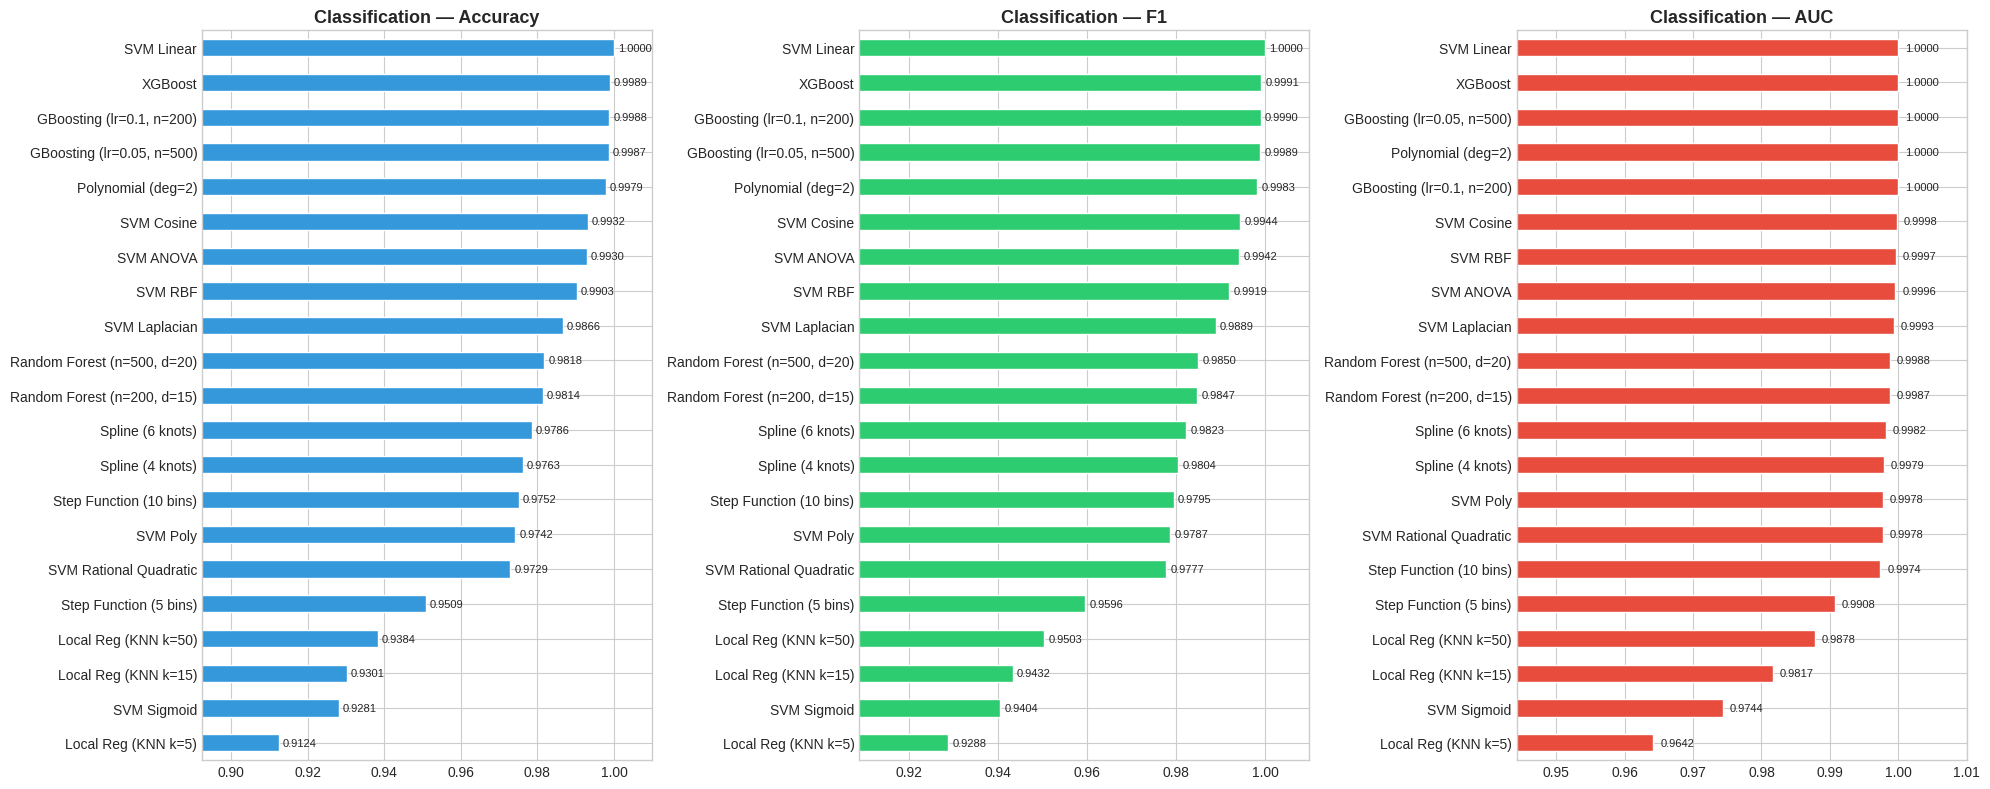

In [21]:
# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, metric, color in zip(axes, ['Accuracy','F1','AUC'], ['#3498db','#2ecc71','#e74c3c']):
    data = clf_df[metric].dropna().sort_values()
    data.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Classification — {metric}', fontsize=13, fontweight='bold')
    ax.set_xlim(data.min()-0.02, data.max()+0.01)
    for i, v in enumerate(data.values):
        ax.text(v+0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


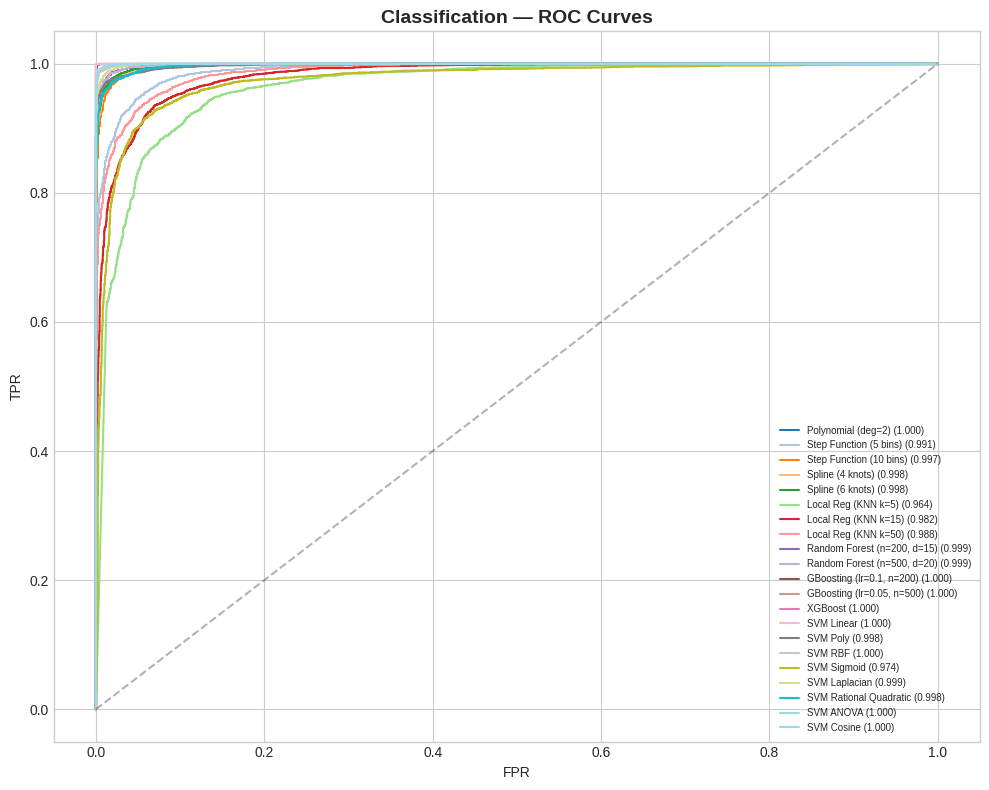

In [22]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.get_cmap('tab20', len(clf_results))
for i, (name, res) in enumerate(clf_results.items()):
    if res['y_prob'] is not None and res['auc'] is not None:
        fpr, tpr, _ = roc_curve(y_clf_test, res['y_prob'])
        ax.plot(fpr, tpr, label=f"{name} ({res['auc']:.3f})", color=cmap(i), lw=1.5)
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Classification — ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.show()


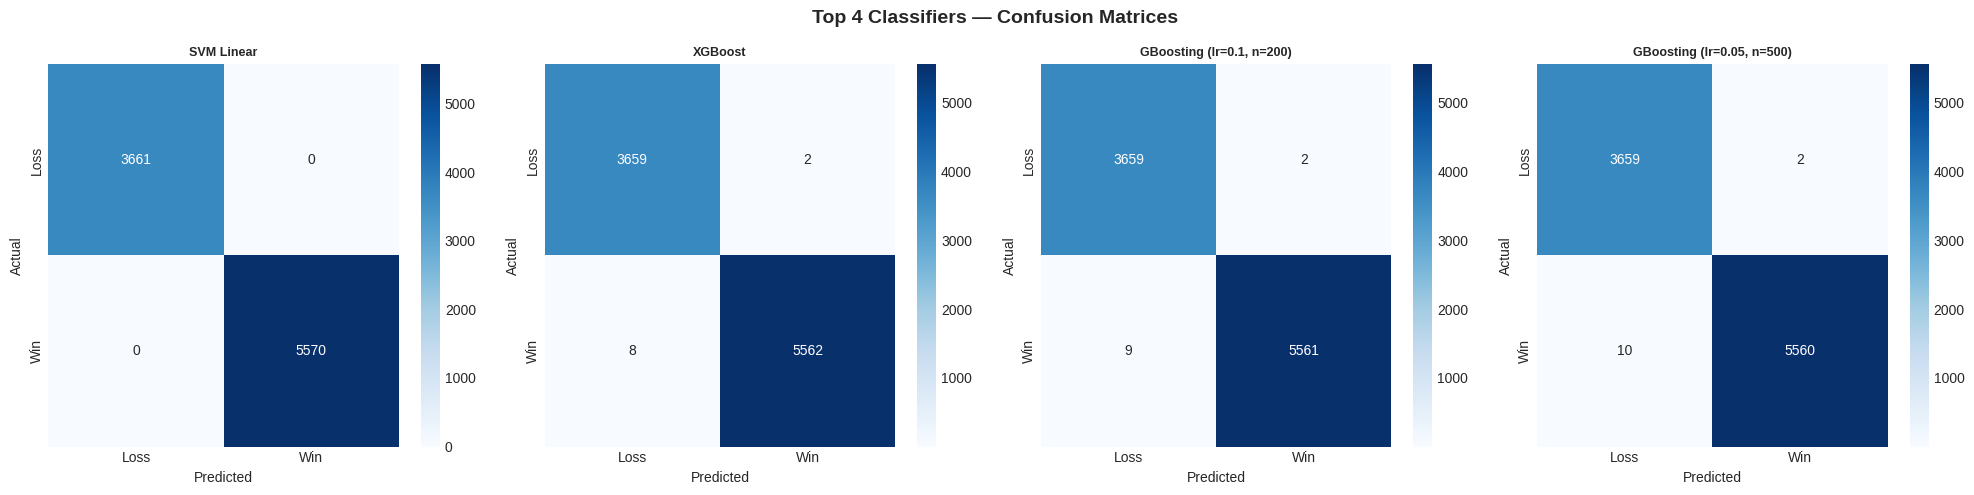

In [23]:
# Confusion matrices — top 4
top4 = clf_df.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, top4):
    cm = confusion_matrix(y_clf_test, clf_results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss','Win'], yticklabels=['Loss','Win'])
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Top 4 Classifiers — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
clf_df

,Accuracy,F1,AUC
SVM Linear,1.0,1.0,1.0
XGBoost,0.998917,0.999102,0.999994
"GBoosting (lr=0.1, n=200)",0.998808,0.999012,0.999972
"GBoosting (lr=0.05, n=500)",0.9987,0.998922,0.999991
Polynomial (deg=2),0.997942,0.998296,0.999981
SVM Cosine,0.993175,0.994353,0.999797
SVM ANOVA,0.992959,0.994159,0.99959
SVM RBF,0.99025,0.991925,0.999691
SVM Laplacian,0.986567,0.988887,0.999348
"Random Forest (n=500, d=20)",0.9818,0.985021,0.998757


In [32]:
import joblib
import os

# Save all SVM models
os.makedirs('saved_models', exist_ok=True)

for name, svm in kernels.items():
    filename = name.lower().replace(' ', '_') + '.joblib'
    joblib.dump(svm, f'saved_models/{filename}')
    print(f"Saved: {filename}")

joblib.dump(rf, f'saved_models/random_forest.joblib')
joblib.dump(rf, f'saved_models/gradientboosting.joblib')
joblib.dump(rf, f'saved_models/random_forest.joblib')
joblib.dump(poly_pipe, f'saved_models/polynomial.joblib')
joblib.dump(spline_pipe, f'saved_models/spline.joblib')
joblib.dump(gam_clf, f'saved_models/gam.joblib')


Saved: svm_linear.joblib
Saved: svm_poly.joblib
Saved: svm_rbf.joblib
Saved: svm_sigmoid.joblib
Saved: svm_laplacian.joblib
Saved: svm_rational_quadratic.joblib
Saved: svm_anova.joblib
Saved: svm_cosine.joblib


['saved_models/gam.joblib']

In [37]:
!zip -r models.zip /kaggle/working/saved_models/

  adding: kaggle/working/saved_models/ (stored 0%)
  adding: kaggle/working/saved_models/svm_laplacian.joblib (deflated 70%)
  adding: kaggle/working/saved_models/gam.joblib (deflated 5%)
  adding: kaggle/working/saved_models/svm_cosine.joblib (deflated 70%)
  adding: kaggle/working/saved_models/svm_rational_quadratic.joblib (deflated 68%)
  adding: kaggle/working/saved_models/svm_rbf.joblib (deflated 68%)
  adding: kaggle/working/saved_models/random_forest.joblib (deflated 77%)
  adding: kaggle/working/saved_models/gradientboosting.joblib (deflated 77%)
  adding: kaggle/working/saved_models/svm_linear.joblib (deflated 65%)
  adding: kaggle/working/saved_models/svm_anova.joblib (deflated 70%)
  adding: kaggle/working/saved_models/svm_sigmoid.joblib (deflated 69%)
  adding: kaggle/working/saved_models/polynomial.joblib (deflated 13%)
  adding: kaggle/working/saved_models/svm_poly.joblib (deflated 72%)
  adding: kaggle/working/saved_models/spline.joblib (deflated 33%)
